In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

os.makedirs("xor_figures", exist_ok=True)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

y = np.array([
    0,
    1,
    1,
    0
], dtype=int)

print("XOR INPUT DATA")
print("=" * 40)

print("Inputs:")
print(X)

print("\nTarget outputs:")
print(y)

XOR INPUT DATA
Inputs:
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]

Target outputs:
[0 1 1 0]


In [3]:
def step_function(z):
    """
    Binary step activation function.
    """
    return 1 if z >= 0 else 0


def predict(x, weights, bias):
    """
    Calculate perceptron prediction.
    """
    z = np.dot(x, weights) + bias
    return step_function(z)


def calculate_update(x, target, prediction, learning_rate):
    """
    Calculate weight and bias updates.
    """
    error = target - prediction

    delta_weights = learning_rate * error * x
    delta_bias = learning_rate * error

    return error, delta_weights, delta_bias

In [9]:
learning_rate = 0.1
max_epochs = 10

weights = np.array([0.0, 0.0])
bias = 0.0

updates = []

update_number = 0

for epoch in range(1, max_epochs + 1):

    errors_in_epoch = 0

    print(f"\n{'=' * 70}")
    print(f"EPOCH {epoch}")
    print(f"{'=' * 70}")

    for i in range(len(X)):

        x = X[i]
        target = y[i]

        # Prediction before update
        z = np.dot(x, weights) + bias
        prediction = step_function(z)

        # Calculate update
        error, delta_weights, delta_bias = calculate_update(
            x,
            target,
            prediction,
            learning_rate
        )

        # Update weights and bias
        weights = weights + delta_weights
        bias = bias + delta_bias

        if error != 0:
            errors_in_epoch += 1
            update_number += 1

            updates.append({
                "Update": update_number,
                "Epoch": epoch,
                "Sample": i + 1,
                "x1": x[0],
                "x2": x[1],
                "Target": target,
                "Prediction": prediction,
                "Error": error,
                "w1": weights[0],
                "w2": weights[1],
                "Bias": bias
            })

            print(
                f"Update {update_number:2d} | "
                f"Input=({int(x[0])},{int(x[1])}) | "
                f"Target={target} | "
                f"Prediction={prediction} | "
                f"Error={error:+d} | "
                f"Weights=({weights[0]:.2f}, {weights[1]:.2f}) | "
                f"Bias={bias:.2f}"
            )

    if errors_in_epoch == 0:
        print("\nConverged successfully!")
        break

else:
    print(
        "\nThe perceptron did not converge within "
        f"{max_epochs} epochs."
    )

print("\nFinal weights:", weights)
print("Final bias:", bias)


EPOCH 1
Update  1 | Input=(0,0) | Target=0 | Prediction=1 | Error=-1 | Weights=(0.00, 0.00) | Bias=-0.10
Update  2 | Input=(0,1) | Target=1 | Prediction=0 | Error=+1 | Weights=(0.00, 0.10) | Bias=0.00
Update  3 | Input=(1,1) | Target=0 | Prediction=1 | Error=-1 | Weights=(-0.10, 0.00) | Bias=-0.10

EPOCH 2
Update  4 | Input=(0,1) | Target=1 | Prediction=0 | Error=+1 | Weights=(-0.10, 0.10) | Bias=0.00
Update  5 | Input=(1,0) | Target=1 | Prediction=0 | Error=+1 | Weights=(0.00, 0.10) | Bias=0.10
Update  6 | Input=(1,1) | Target=0 | Prediction=1 | Error=-1 | Weights=(-0.10, 0.00) | Bias=0.00

EPOCH 3
Update  7 | Input=(0,0) | Target=0 | Prediction=1 | Error=-1 | Weights=(-0.10, 0.00) | Bias=-0.10
Update  8 | Input=(0,1) | Target=1 | Prediction=0 | Error=+1 | Weights=(-0.10, 0.10) | Bias=0.00
Update  9 | Input=(1,0) | Target=1 | Prediction=0 | Error=+1 | Weights=(0.00, 0.10) | Bias=0.10
Update 10 | Input=(1,1) | Target=0 | Prediction=1 | Error=-1 | Weights=(-0.10, 0.00) | Bias=0.00

EPO

In [10]:
final_predictions = []

for x in X:
    prediction = predict(
        x,
        weights,
        bias
    )

    final_predictions.append(prediction)

final_predictions = np.array(final_predictions)

final_results = pd.DataFrame({
    "x1": X[:, 0].astype(int),
    "x2": X[:, 1].astype(int),
    "Actual XOR": y,
    "Final Prediction": final_predictions
})

print("=" * 60)
print("FINAL XOR PREDICTIONS")
print("=" * 60)

display(final_results)

FINAL XOR PREDICTIONS


,x1,x2,Actual XOR,Final Prediction
0,0,0,0,1
1,0,1,1,1
2,1,0,1,0
3,1,1,0,0


In [11]:
def plot_decision_boundary(
    weights,
    bias,
    X,
    y,
    update_number,
    epoch,
    save_path
):

    plt.figure(figsize=(7, 6))

    # Plot class 0
    class_0 = y == 0
    plt.scatter(
        X[class_0, 0],
        X[class_0, 1],
        marker="o",
        s=150,
        label="Class 0"
    )

    # Plot class 1
    class_1 = y == 1
    plt.scatter(
        X[class_1, 0],
        X[class_1, 1],
        marker="s",
        s=150,
        label="Class 1"
    )

    # Decision boundary
    x_values = np.linspace(-0.5, 1.5, 200)

    if abs(weights[1]) > 1e-10:
        y_values = (
            -(weights[0] * x_values + bias)
            / weights[1]
        )

        plt.plot(
            x_values,
            y_values,
            linewidth=2,
            label="Decision Boundary"
        )

    elif abs(weights[0]) > 1e-10:
        x_boundary = -bias / weights[0]

        plt.axvline(
            x_boundary,
            linewidth=2,
            label="Decision Boundary"
        )

    plt.xlim(-0.5, 1.5)
    plt.ylim(-0.5, 1.5)

    plt.xlabel("x₁")
    plt.ylabel("x₂")

    plt.title(
        f"XOR Perceptron Decision Boundary\n"
        f"After Update {update_number} | Epoch {epoch}"
    )

    plt.grid(True)
    plt.legend()

    plt.tight_layout()

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

In [13]:
# Create the weight-update DataFrame

updates_df = pd.DataFrame(updates)

print("=" * 80)
print("WEIGHT UPDATE RECORDS")
print("=" * 80)

display(updates_df)

WEIGHT UPDATE RECORDS


,Update,Epoch,Sample,x1,x2,Target,Prediction,Error,w1,w2,Bias
0,1,1,1,0.0,0.0,0,1,-1,0.0,0.0,-0.1
1,2,1,2,0.0,1.0,1,0,1,0.0,0.1,0.0
2,3,1,4,1.0,1.0,0,1,-1,-0.1,0.0,-0.1
3,4,2,2,0.0,1.0,1,0,1,-0.1,0.1,0.0
4,5,2,3,1.0,0.0,1,0,1,0.0,0.1,0.1
5,6,2,4,1.0,1.0,0,1,-1,-0.1,0.0,0.0
6,7,3,1,0.0,0.0,0,1,-1,-0.1,0.0,-0.1
7,8,3,2,0.0,1.0,1,0,1,-0.1,0.1,0.0
8,9,3,3,1.0,0.0,1,0,1,0.0,0.1,0.1
9,10,3,4,1.0,1.0,0,1,-1,-0.1,0.0,0.0


GENERATING DECISION BOUNDARY PLOTS


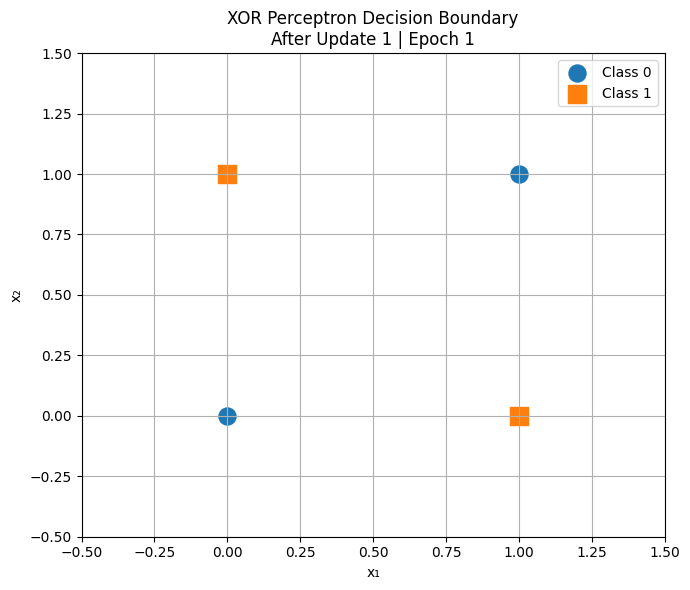

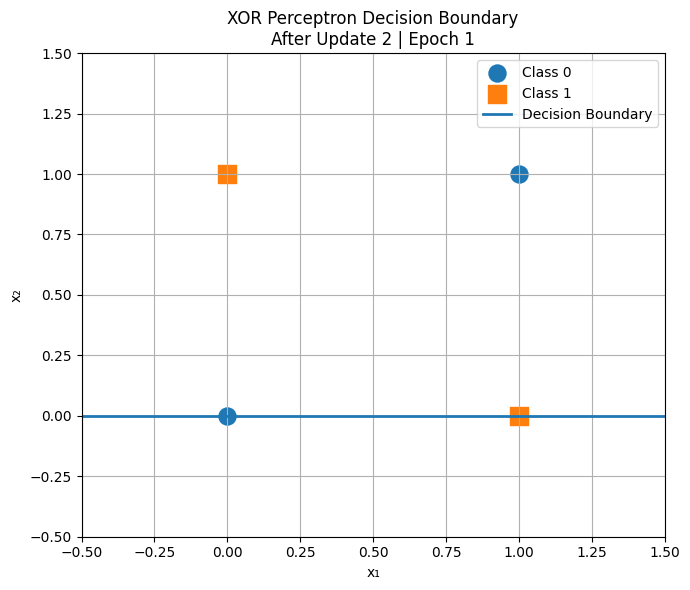

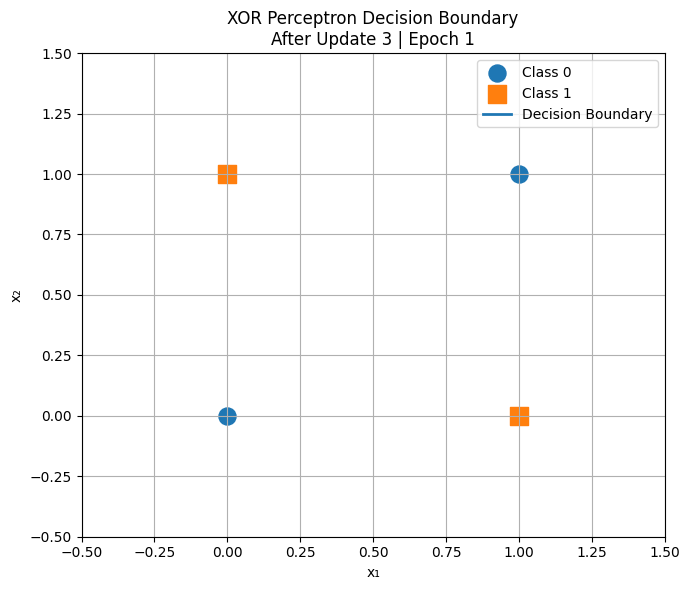

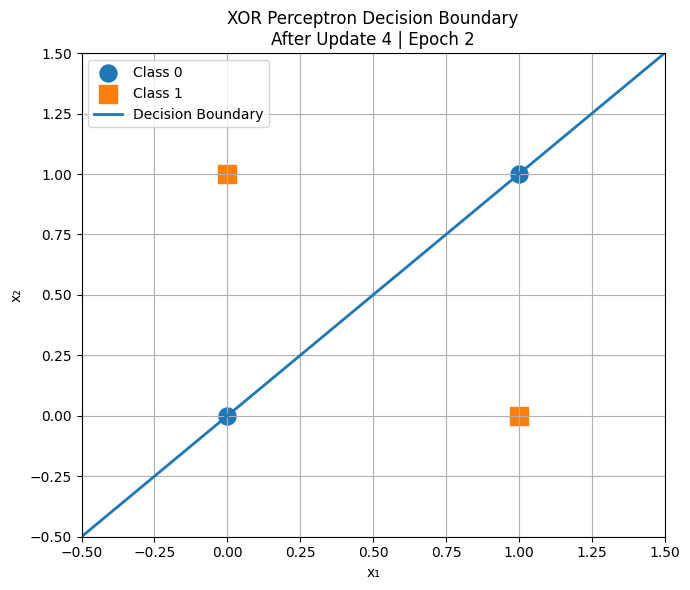

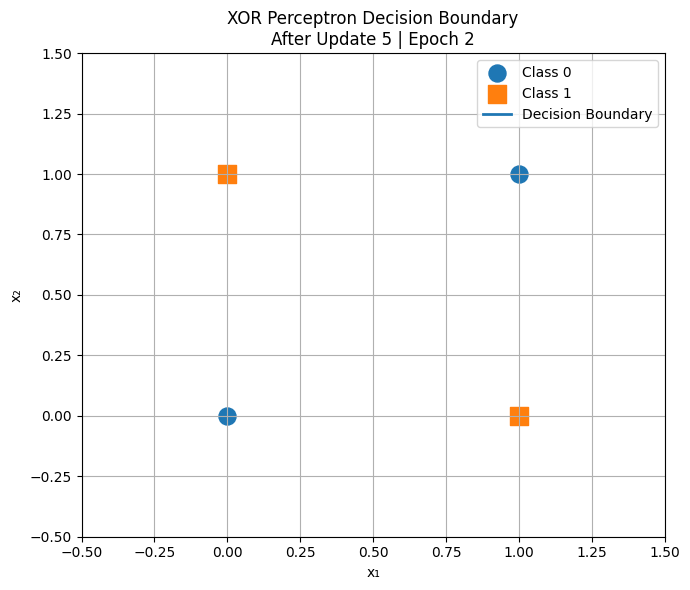

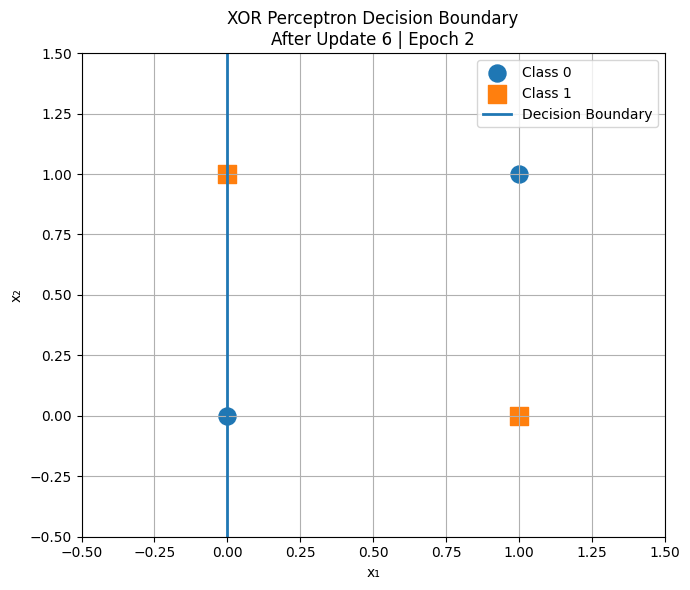

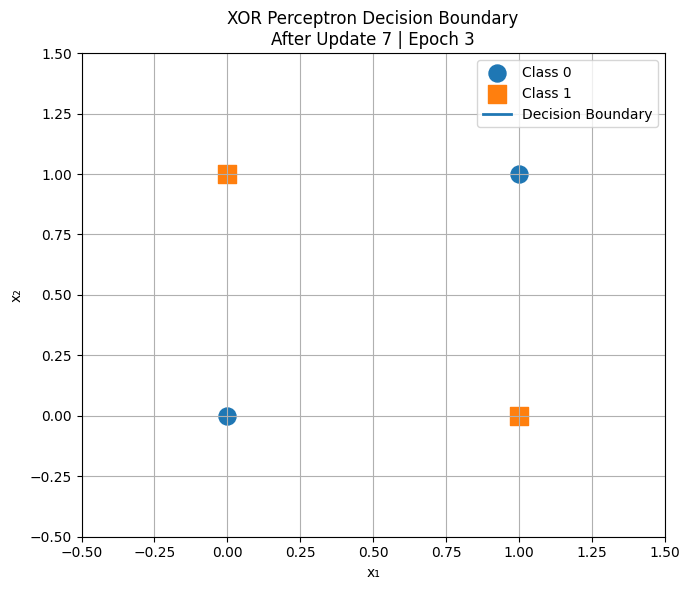

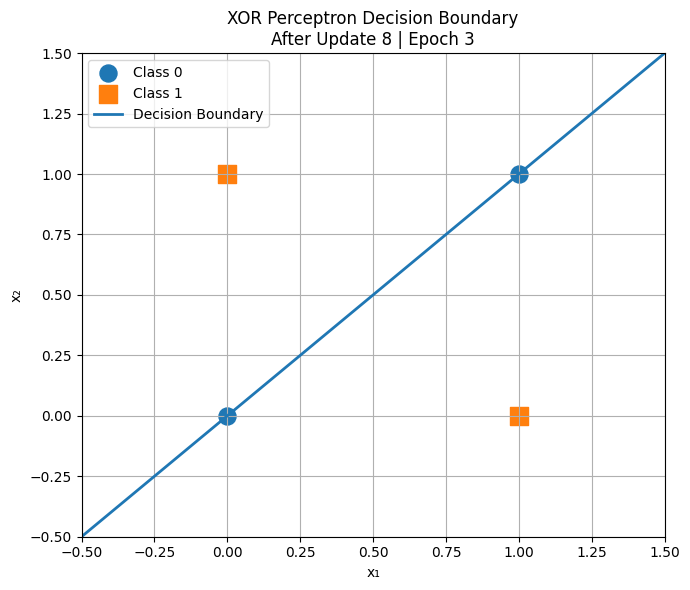

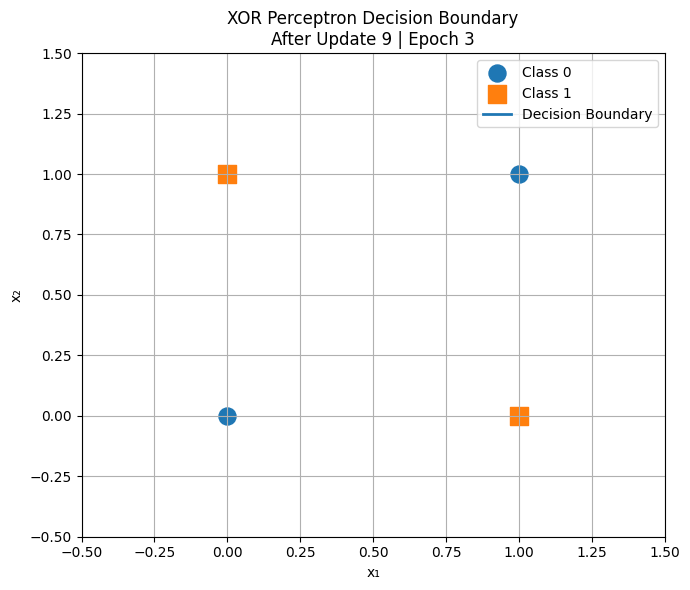

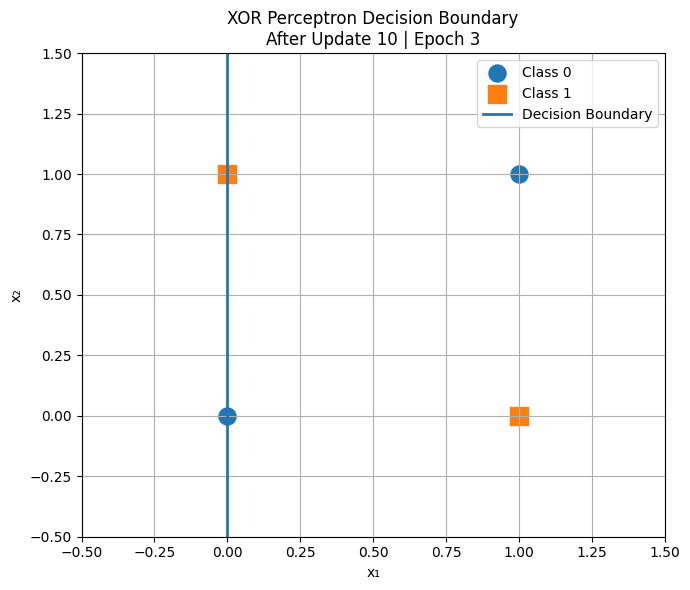

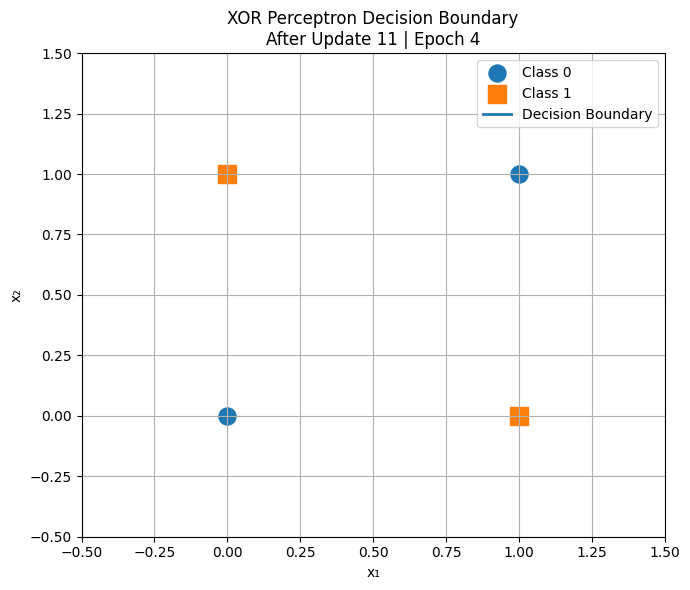

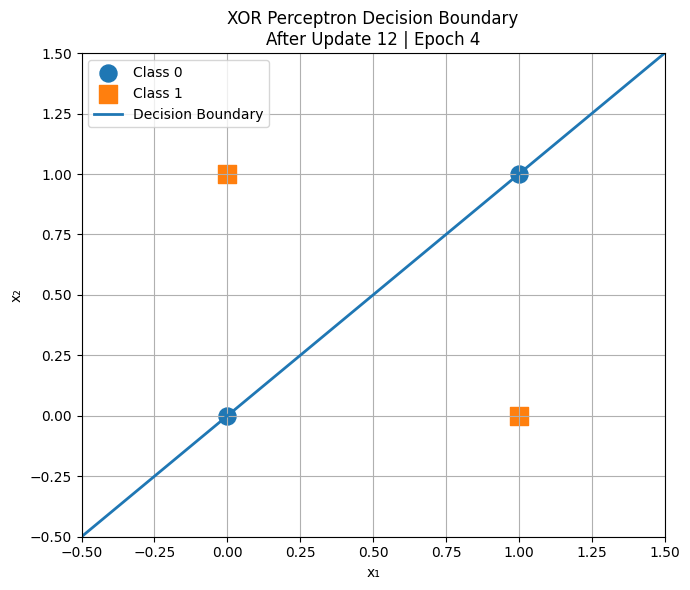

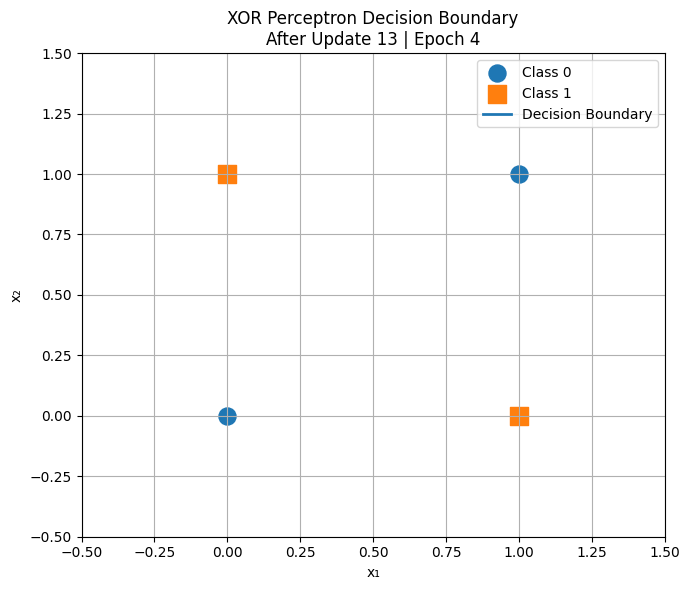

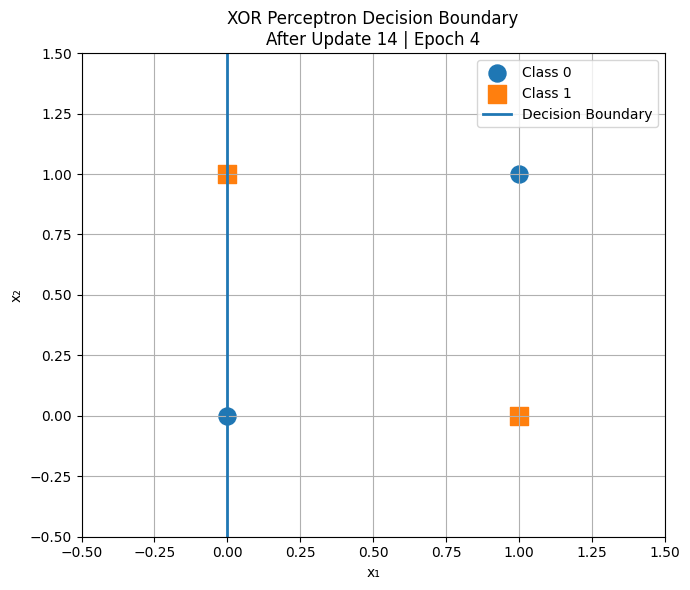

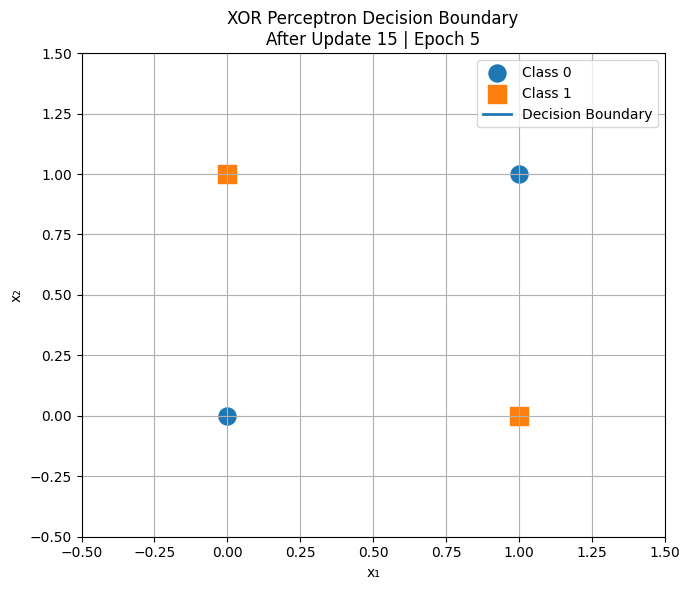

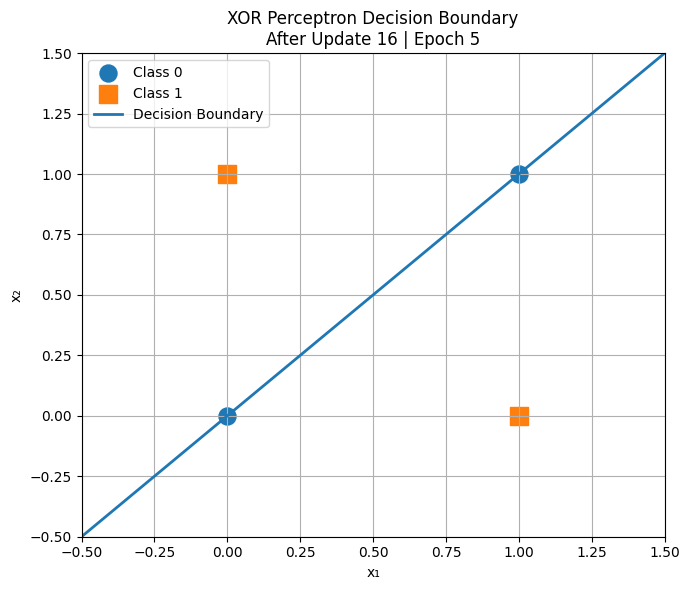

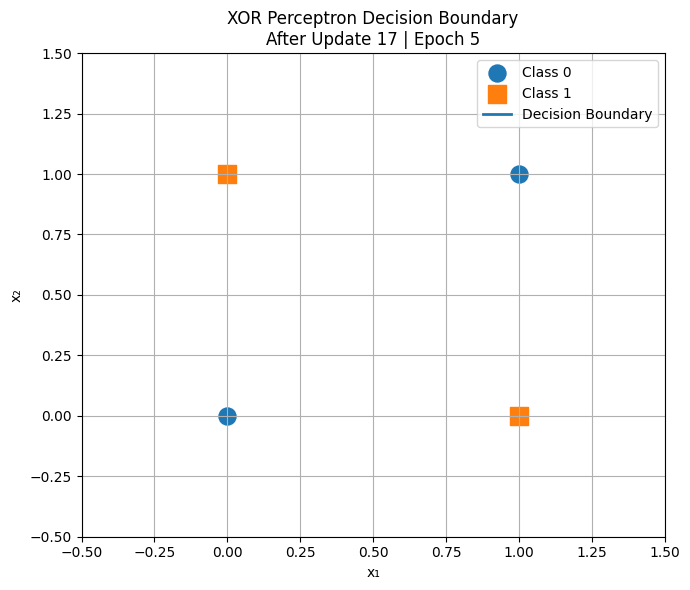

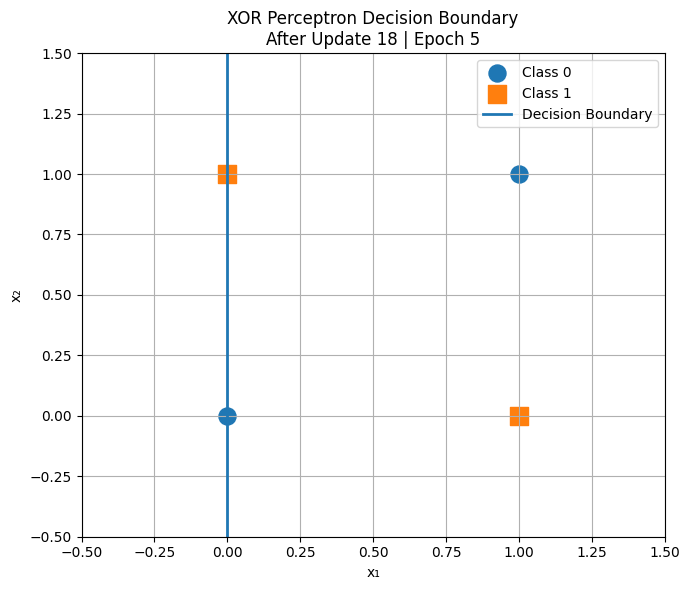

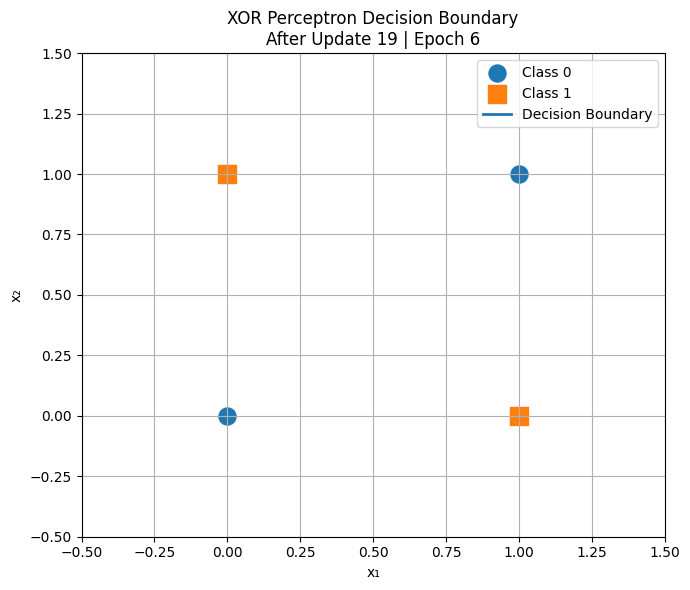

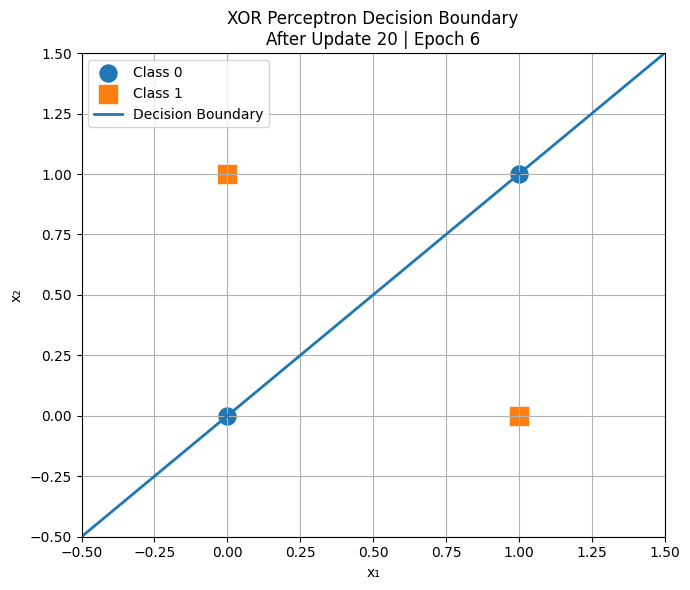

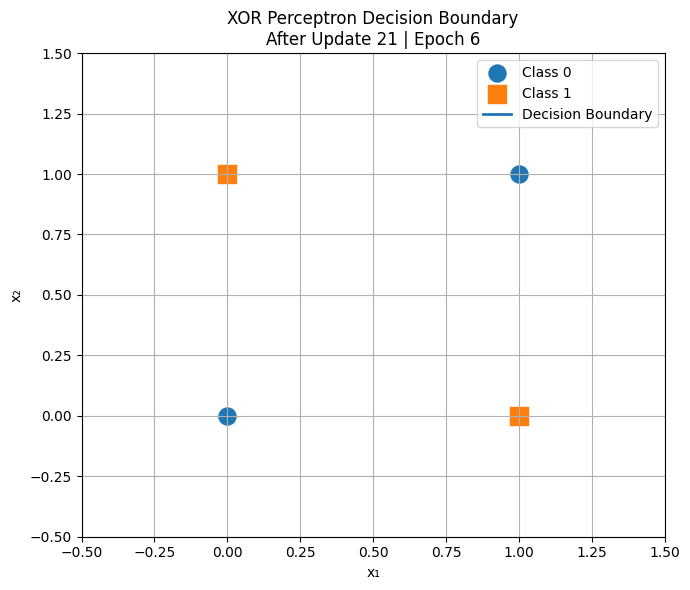

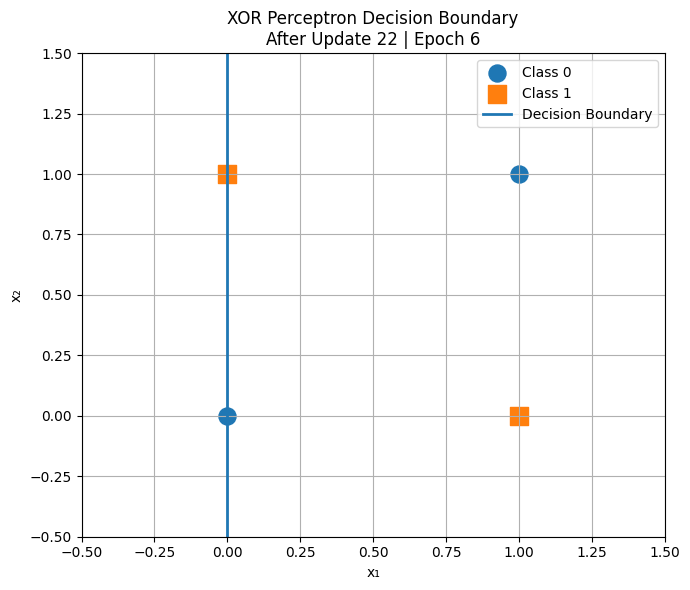

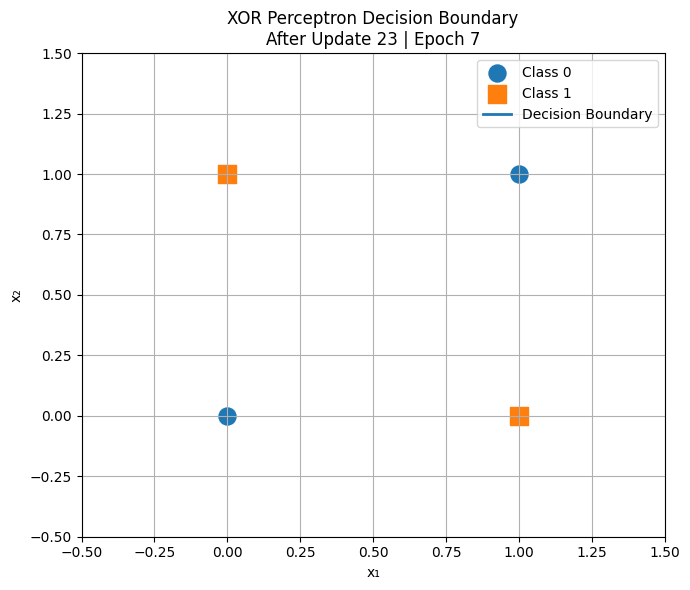

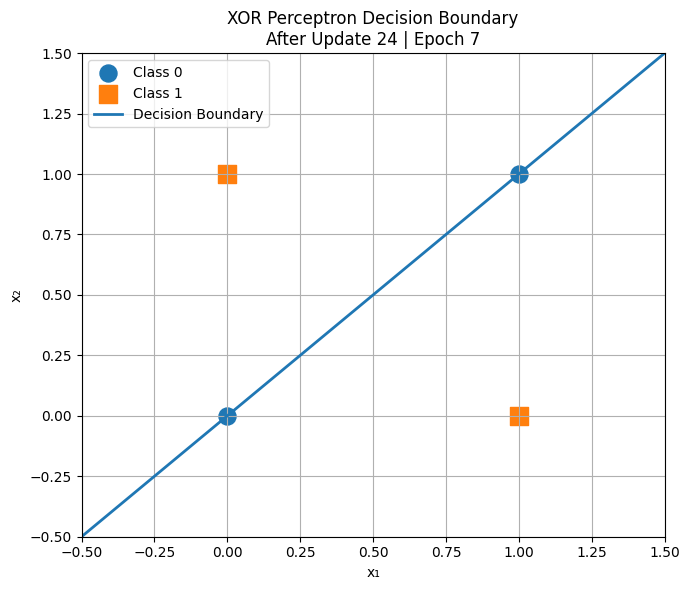

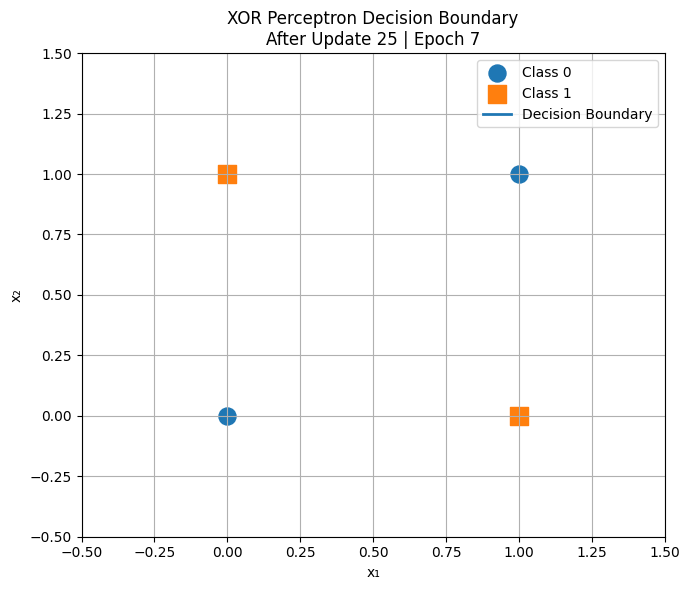

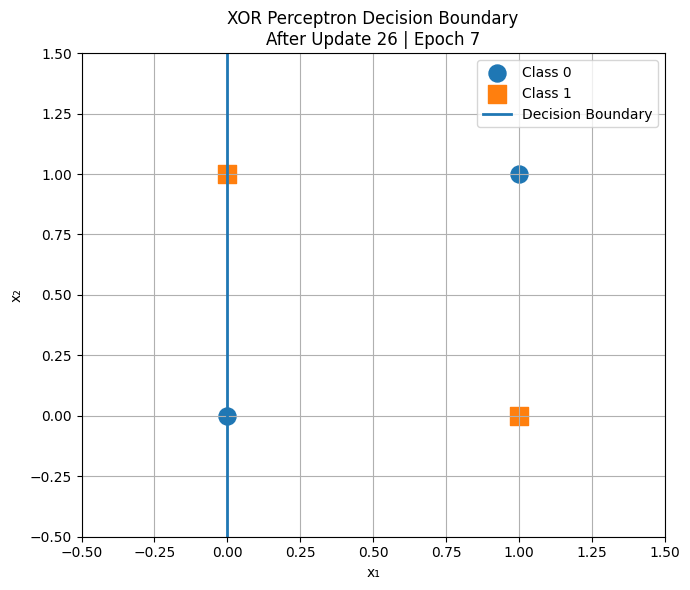

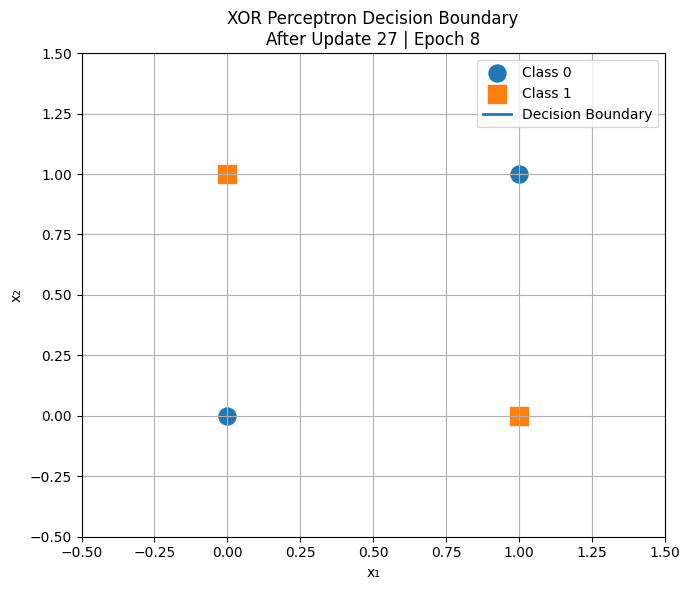

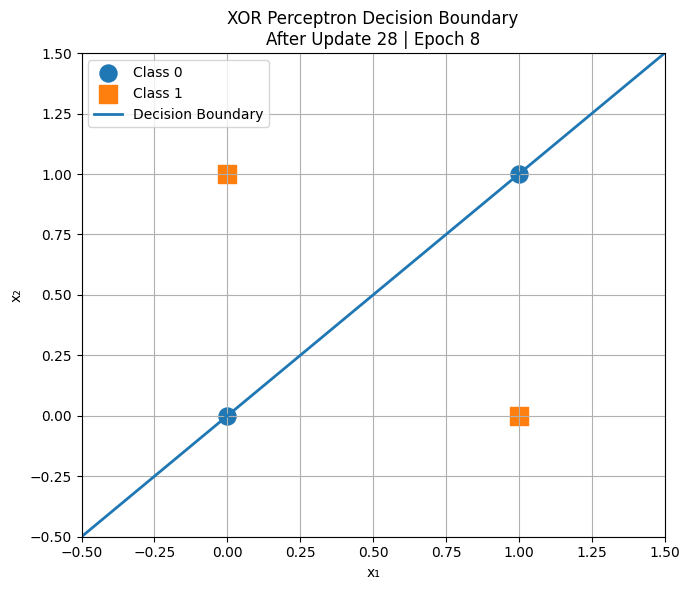

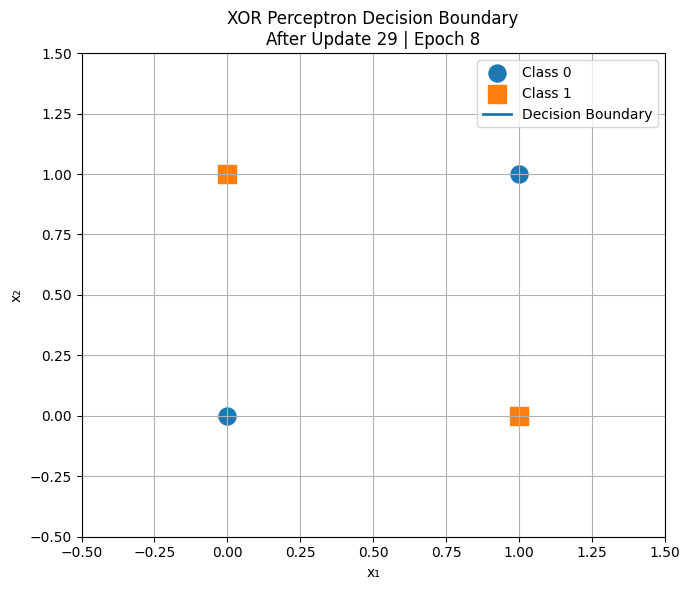

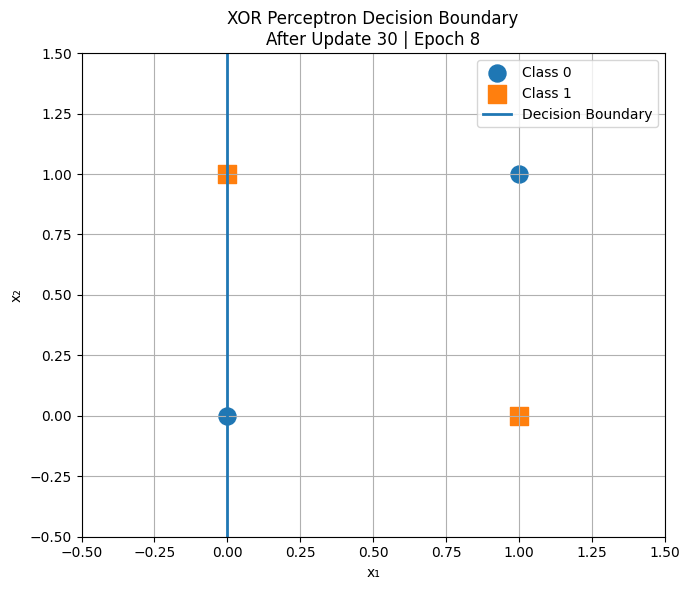

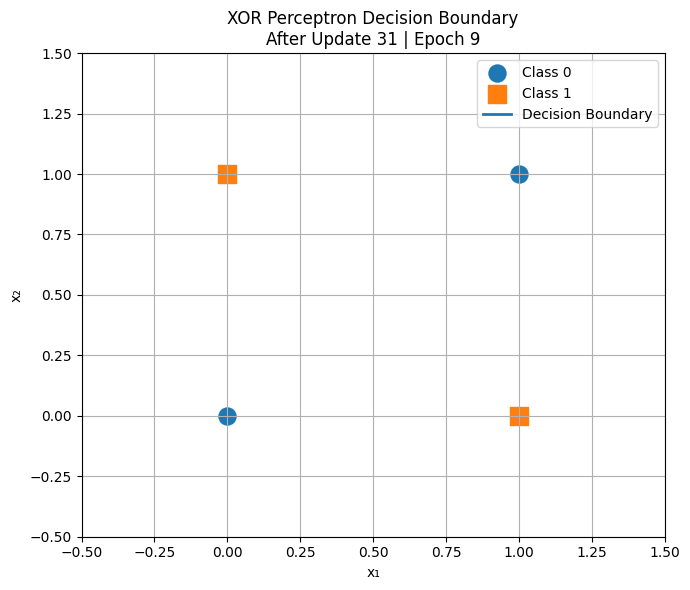

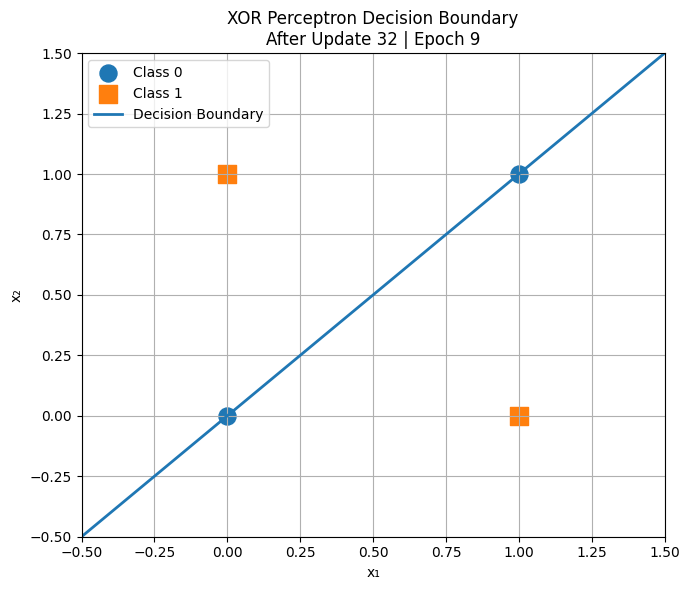

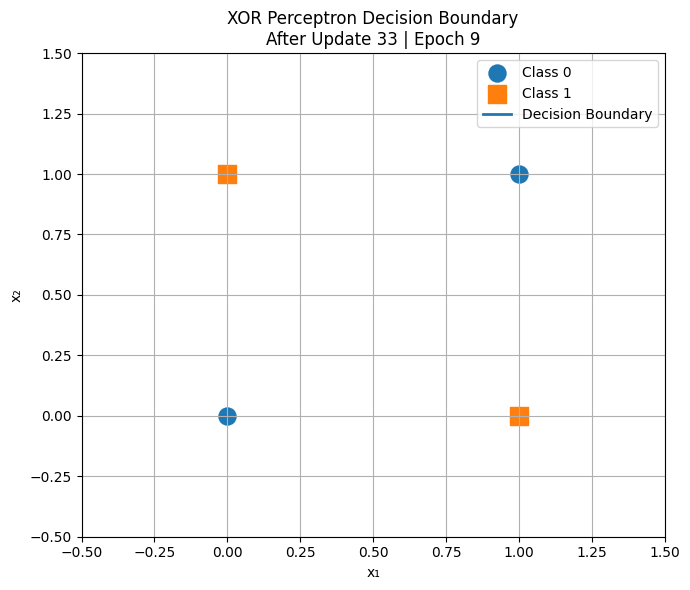

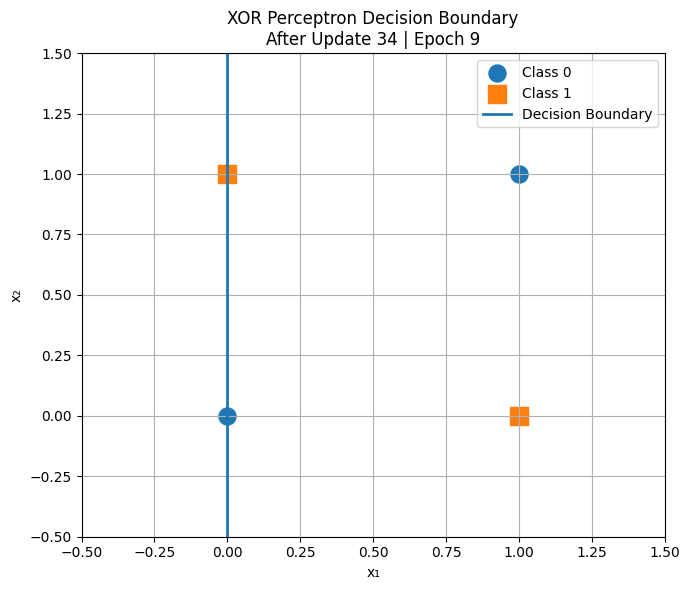

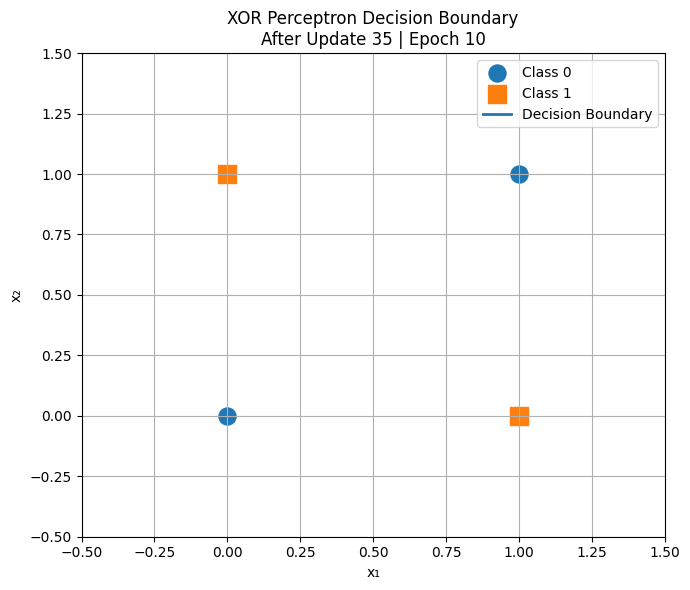

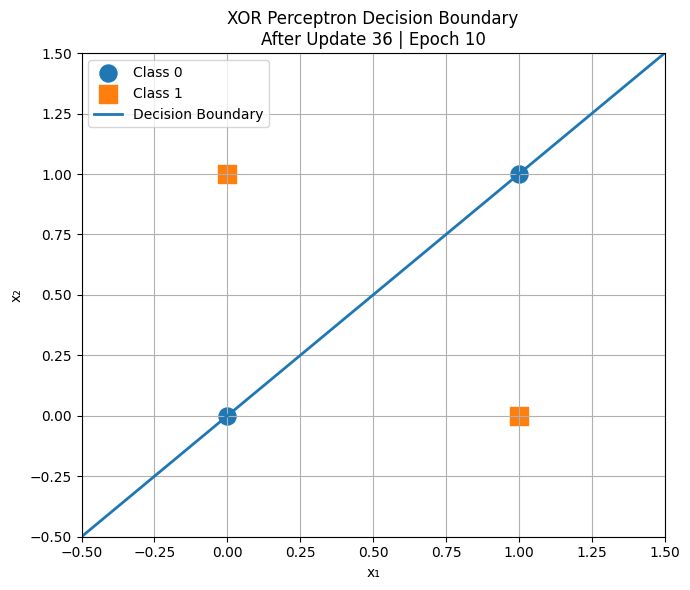

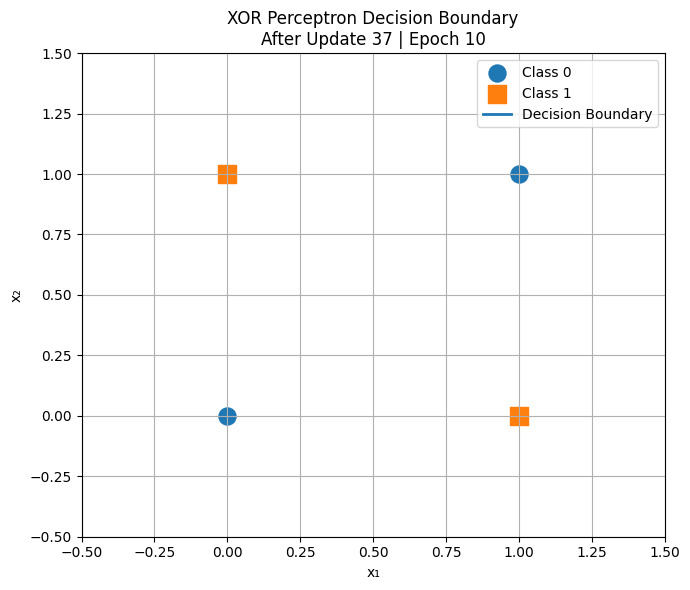

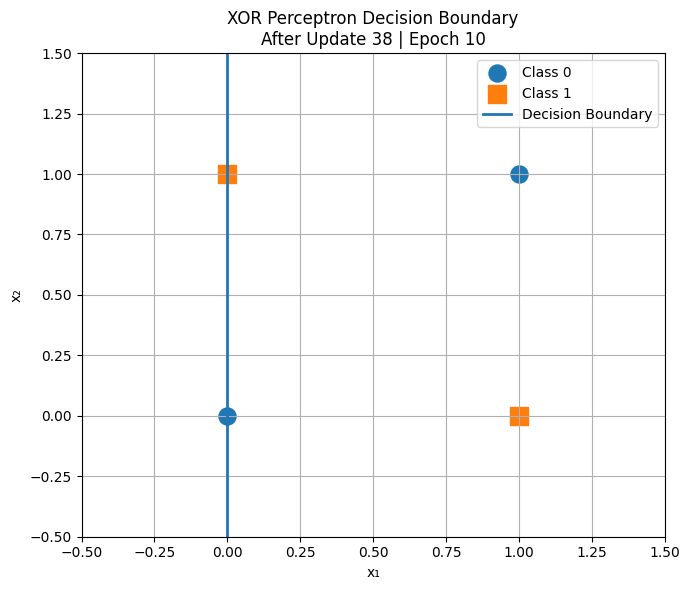

All decision-boundary plots generated.


In [14]:
print("=" * 70)
print("GENERATING DECISION BOUNDARY PLOTS")
print("=" * 70)

for _, row in updates_df.iterrows():

    update_no = int(row["Update"])

    update_weights = np.array([
        row["w1"],
        row["w2"]
    ])

    update_bias = row["Bias"]

    epoch = int(row["Epoch"])

    filename = (
        f"xor_figures/"
        f"update_{update_no:02d}.png"
    )

    plot_decision_boundary(
        update_weights,
        update_bias,
        X,
        y,
        update_no,
        epoch,
        filename
    )

print("All decision-boundary plots generated.")

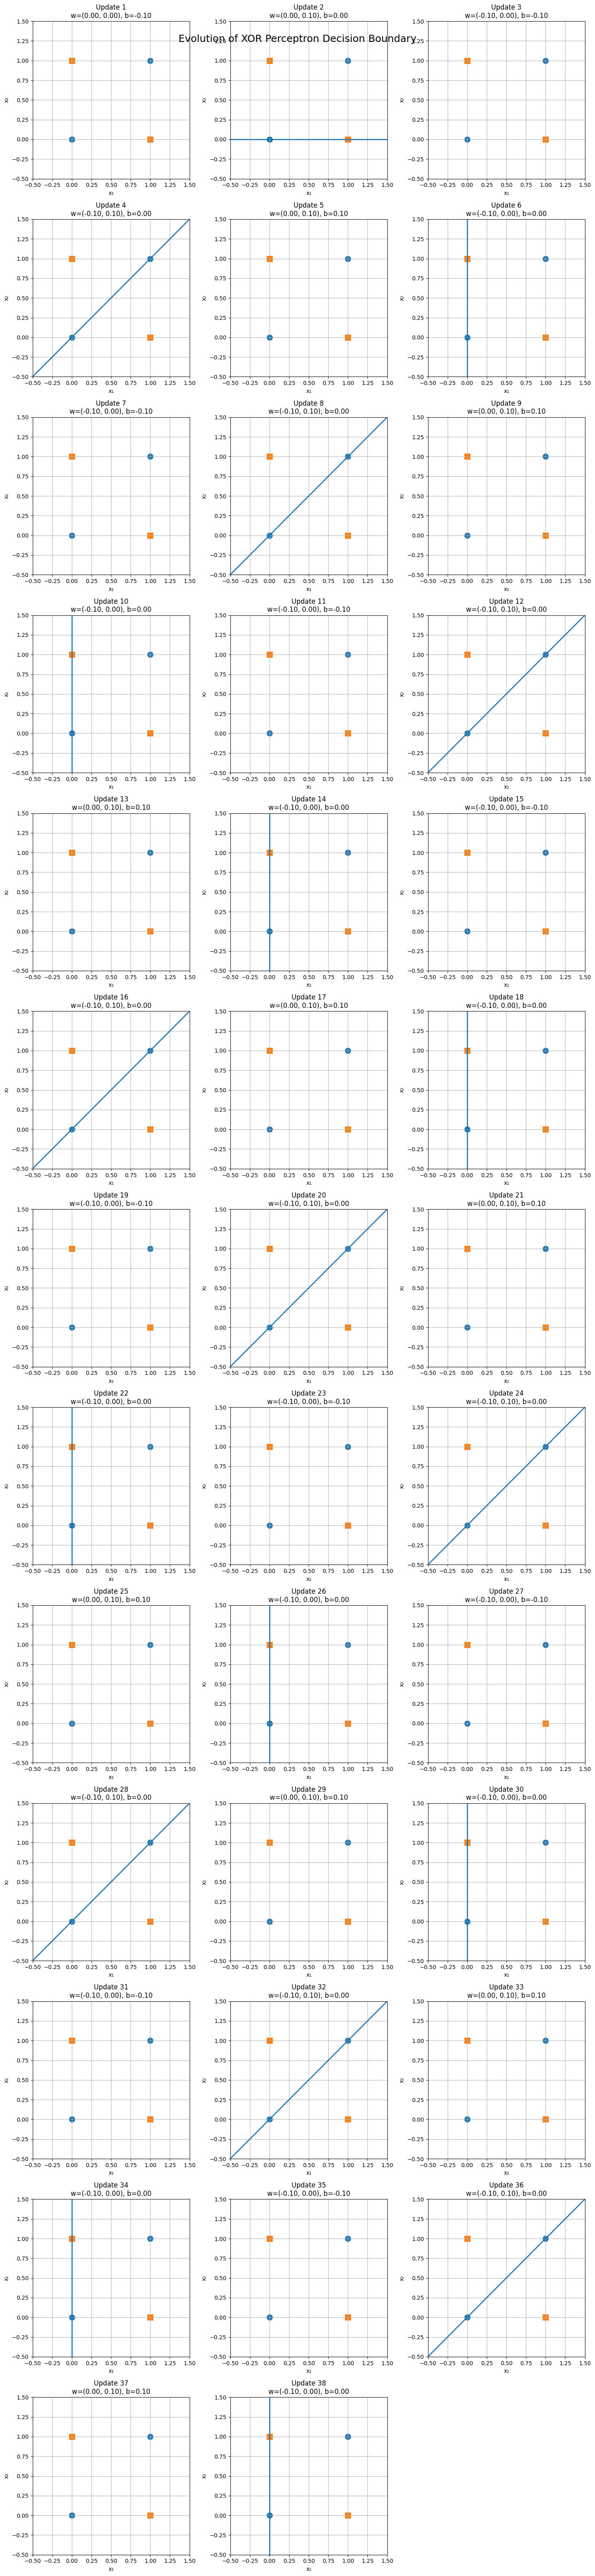

In [15]:
num_updates = len(updates_df)

cols = 3
rows = int(np.ceil(num_updates / cols))

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(15, 5 * rows)
)

axes = np.array(axes).reshape(-1)

for ax, (_, row) in zip(
    axes,
    updates_df.iterrows()
):

    update_no = int(row["Update"])

    update_weights = np.array([
        row["w1"],
        row["w2"]
    ])

    update_bias = row["Bias"]

    epoch = int(row["Epoch"])

    # Class 0
    class_0 = y == 0

    ax.scatter(
        X[class_0, 0],
        X[class_0, 1],
        marker="o",
        s=100,
        label="Class 0"
    )

    # Class 1
    class_1 = y == 1

    ax.scatter(
        X[class_1, 0],
        X[class_1, 1],
        marker="s",
        s=100,
        label="Class 1"
    )

    # Boundary
    x_values = np.linspace(-0.5, 1.5, 200)

    if abs(update_weights[1]) > 1e-10:

        y_values = (
            -(update_weights[0] * x_values + update_bias)
            / update_weights[1]
        )

        ax.plot(
            x_values,
            y_values,
            linewidth=2
        )

    elif abs(update_weights[0]) > 1e-10:

        x_boundary = (
            -update_bias /
            update_weights[0]
        )

        ax.axvline(
            x_boundary,
            linewidth=2
        )

    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)

    ax.set_xlabel("x₁")
    ax.set_ylabel("x₂")

    ax.set_title(
        f"Update {update_no}\n"
        f"w=({row['w1']:.2f}, {row['w2']:.2f}), "
        f"b={row['Bias']:.2f}"
    )

    ax.grid(True)

# Hide unused axes
for ax in axes[num_updates:]:
    ax.axis("off")

fig.suptitle(
    "Evolution of XOR Perceptron Decision Boundary",
    fontsize=18
)

plt.tight_layout()

plt.savefig(
    "xor_figures/xor_decision_boundary_evolution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

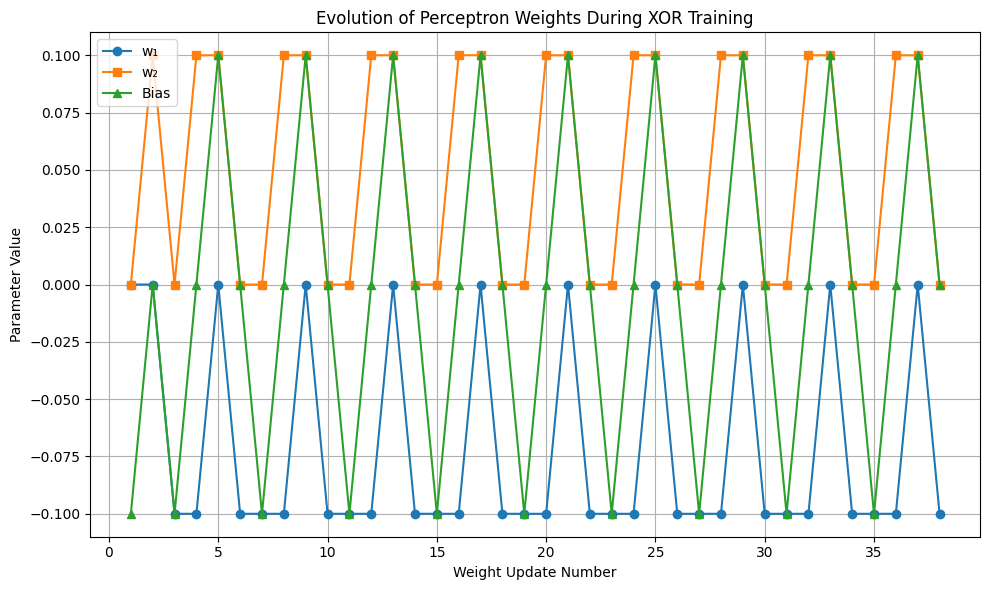

In [16]:
plt.figure(figsize=(10, 6))

plt.plot(
    updates_df["Update"],
    updates_df["w1"],
    marker="o",
    label="w₁"
)

plt.plot(
    updates_df["Update"],
    updates_df["w2"],
    marker="s",
    label="w₂"
)

plt.plot(
    updates_df["Update"],
    updates_df["Bias"],
    marker="^",
    label="Bias"
)

plt.xlabel("Weight Update Number")
plt.ylabel("Parameter Value")

plt.title(
    "Evolution of Perceptron Weights During XOR Training"
)

plt.grid(True)
plt.legend()

plt.tight_layout()

plt.savefig(
    "xor_figures/xor_weight_evolution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

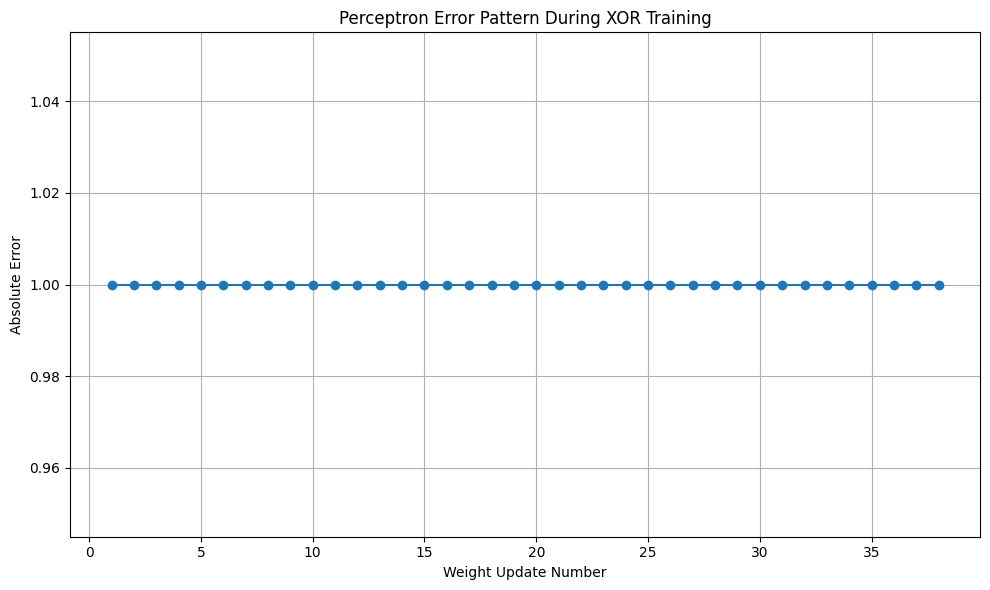

In [17]:
plt.figure(figsize=(10, 6))

plt.plot(
    updates_df["Update"],
    np.abs(updates_df["Error"]),
    marker="o"
)

plt.xlabel("Weight Update Number")
plt.ylabel("Absolute Error")

plt.title(
    "Perceptron Error Pattern During XOR Training"
)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "xor_figures/xor_error_pattern.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [18]:
print("=" * 75)
print("XOR PERCEPTRON CONVERGENCE ANALYSIS")
print("=" * 75)

print(f"Learning Rate       : {learning_rate}")
print(f"Maximum Epochs      : {max_epochs}")
print(f"Total Updates       : {len(updates_df)}")

print("\nFinal Weights")
print(f"w1                  : {weights[0]:.4f}")
print(f"w2                  : {weights[1]:.4f}")
print(f"Bias                : {bias:.4f}")

print("\n" + "-" * 75)

if len(updates_df) > 0:

    print(
        "Result: The perceptron did NOT converge "
        "within the specified number of epochs."
    )

    print("\nReason:")
    print(
        "XOR is not linearly separable."
    )

    print(
        "A single straight-line decision boundary "
        "cannot correctly separate the two XOR classes."
    )

    print(
        "Therefore, whenever the perceptron corrects one "
        "misclassified XOR point, the boundary can cause "
        "another XOR point to become misclassified."
    )

print("=" * 75)

XOR PERCEPTRON CONVERGENCE ANALYSIS
Learning Rate       : 0.1
Maximum Epochs      : 10
Total Updates       : 38

Final Weights
w1                  : -0.1000
w2                  : 0.0000
Bias                : 0.0000

---------------------------------------------------------------------------
Result: The perceptron did NOT converge within the specified number of epochs.

Reason:
XOR is not linearly separable.
A single straight-line decision boundary cannot correctly separate the two XOR classes.
Therefore, whenever the perceptron corrects one misclassified XOR point, the boundary can cause another XOR point to become misclassified.


In [19]:
updates_df.to_csv(
    "xor_figures/xor_weight_updates.csv",
    index=False
)

print("Weight-update table saved successfully.")

Weight-update table saved successfully.


In [20]:
import shutil
from google.colab import files

shutil.make_archive(
    "XOR_Perceptron_Figures",
    "zip",
    "xor_figures"
)

files.download(
    "XOR_Perceptron_Figures.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>